In [ ]:
os.listdir()


NameError: name 'os' is not defined

In [ ]:
import os
print(os.listdir())


['.config', 'Bitext_Sample_Customer_Service_Training_Dataset.csv', 'sample_data']


In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1: load and inspect
df2 = pd.read_csv("Bitext_Sample_Customer_Service_Training_Dataset.cs")  # use exact filename from os.listdir()
print(df2.shape)
print(df2.columns.tolist())
print(df2['category'].value_counts())

# Step 2a: build urgency labels ourselves (no ground truth exists — documented, transparent rule)
urgent_keywords = ['urgent', 'immediately', 'asap', 'emergency', 'critical',
                    "can't access", 'cannot access', 'broken', 'not working',
                    'unable to', 'locked out', 'failed', 'error', 'help me']

def assign_urgency(text):
    text = str(text).lower()
    matches = sum(1 for kw in urgent_keywords if kw in text)
    if matches >= 2:
        return 'High'
    elif matches == 1:
        return 'Medium'
    else:
        return 'Low'

df2['urgency'] = df2['instruction'].apply(assign_urgency)
print(df2['urgency'].value_counts())

# Step 2b: clean text
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df2['clean_text'] = df2['instruction'].apply(clean_text)
model_df = df2[['clean_text', 'category', 'urgency']].copy()
model_df.columns = ['text', 'category', 'urgency']
print(model_df.head())

# Step 3: split + TF-IDF
X_train, X_test, y_cat_train, y_cat_test, y_urg_train, y_urg_test = train_test_split(
    model_df['text'], model_df['category'], model_df['urgency'],
    test_size=0.2, random_state=42, stratify=model_df['category']
)

tfidf = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(X_train_tfidf.shape, X_test_tfidf.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'Bitext_Sample_Customer_Service_Training_Dataset.cs'

In [ ]:
import os
print(os.listdir())


['.config', 'Bitext_Sample_Customer_Service_Training_Dataset.csv', 'sample_data']


In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1: load and inspect
df2 = pd.read_csv("Bitext_Sample_Customer_Service_Training_Dataset.csv")
print(df2.shape)
print(df2.columns.tolist())
print(df2['category'].value_counts())

# Step 2a: build urgency labels ourselves (no ground truth exists — documented, transparent rule)
urgent_keywords = ['urgent', 'immediately', 'asap', 'emergency', 'critical',
                    "can't access", 'cannot access', 'broken', 'not working',
                    'unable to', 'locked out', 'failed', 'error', 'help me']

def assign_urgency(text):
    text = str(text).lower()
    matches = sum(1 for kw in urgent_keywords if kw in text)
    if matches >= 2:
        return 'High'
    elif matches == 1:
        return 'Medium'
    else:
        return 'Low'

category_urgency_map = {
    'ACCOUNT': 'High', 'PAYMENT': 'High', 'REFUND': 'High',
    'ORDER': 'Medium', 'DELIVERY': 'Medium', 'SHIPPING_ADDRESS': 'Medium',
    'INVOICE': 'Medium', 'CANCELLATION_FEE': 'Medium',
    'FEEDBACK': 'Low', 'NEWSLETTER': 'Low', 'CONTACT': 'Low'
}

high_keywords = ['urgent', 'immediately', 'asap', 'emergency', 'critical',
                  "can't access", 'cannot access', 'locked out', 'not working',
                  'broken', 'failed', 'stuck', 'right now']

def assign_urgency(row):
    text = str(row['utterance']).lower()
    if any(kw in text for kw in high_keywords):
        return 'High'
    return category_urgency_map.get(row['category'], 'Medium')

df2['urgency'] = df2.apply(assign_urgency, axis=1)
print(df2['urgency'].value_counts())

df2['clean_text'] = df2['utterance'].apply(clean_text)
model_df = df2[['clean_text', 'category', 'urgency']].copy()
model_df.columns = ['text', 'category', 'urgency']
print(model_df.head())

# Step 3: split + TF-IDF
X_train, X_test, y_cat_train, y_cat_test, y_urg_train, y_urg_test = train_test_split(
    model_df['text'], model_df['category'], model_df['urgency'],
    test_size=0.2, random_state=42, stratify=model_df['category']
)

tfidf = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(X_train_tfidf.shape, X_test_tfidf.shape)


(8175, 4)
['flags', 'utterance', 'category', 'intent']
category
ACCOUNT             1774
ORDER               1220
REFUND               904
INVOICE              648
PAYMENT              620
FEEDBACK             613
SHIPPING_ADDRESS     604
DELIVERY             603
CONTACT              596
CANCELLATION_FEE     298
NEWSLETTER           295
Name: count, dtype: int64
urgency
Medium    3373
High      3298
Low       1504
Name: count, dtype: int64
                                                text category urgency
0            i have problems with canceling an order    ORDER  Medium
1  how can i find information about canceling orders    ORDER  Medium
2          i need help with canceling the last order    ORDER  Medium
3  could you help me cancelling the last order i ...    ORDER  Medium
4            problem with cancelling an order i made    ORDER  Medium
(6540, 2770) (1635, 2770)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Category classifier
category_model = LogisticRegression(max_iter=1000, random_state=42)
category_model.fit(X_train_tfidf, y_cat_train)

# Urgency classifier
urgency_model = LogisticRegression(max_iter=1000, random_state=42)
urgency_model.fit(X_train_tfidf, y_urg_train)

cat_preds = category_model.predict(X_test_tfidf)
urg_preds = urgency_model.predict(X_test_tfidf)

print("Category accuracy:", accuracy_score(y_cat_test, cat_preds))
print("Urgency accuracy:", accuracy_score(y_urg_test, urg_preds))

Category accuracy: 0.9969418960244648
Urgency accuracy: 0.998776758409786


=== Category Classification Report ===
                  precision    recall  f1-score   support

         ACCOUNT       0.99      1.00      0.99       355
CANCELLATION_FEE       1.00      0.98      0.99        59
         CONTACT       0.99      1.00      1.00       119
        DELIVERY       0.99      1.00      1.00       121
        FEEDBACK       1.00      1.00      1.00       122
         INVOICE       1.00      1.00      1.00       130
      NEWSLETTER       1.00      1.00      1.00        59
           ORDER       1.00      1.00      1.00       244
         PAYMENT       1.00      0.99      1.00       124
          REFUND       1.00      0.99      1.00       181
SHIPPING_ADDRESS       1.00      0.99      1.00       121

        accuracy                           1.00      1635
       macro avg       1.00      1.00      1.00      1635
    weighted avg       1.00      1.00      1.00      1635

=== Urgency Classification Report ===
              precision    recall  f1-score   supp

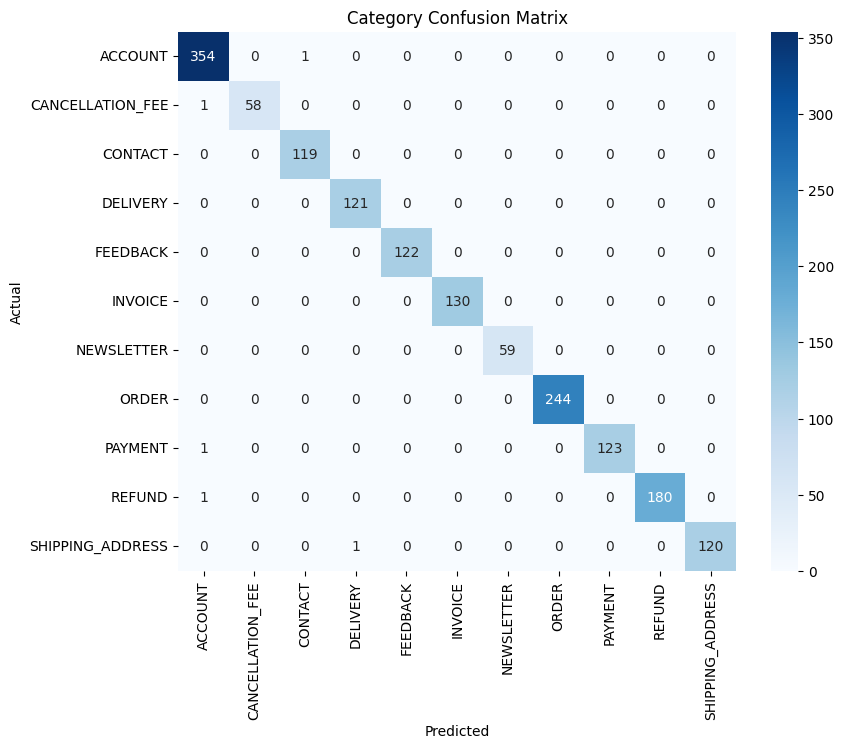

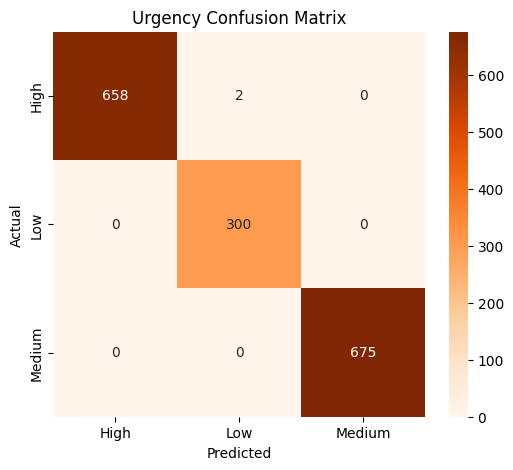

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Category Classification Report ===")
print(classification_report(y_cat_test, cat_preds))

print("=== Urgency Classification Report ===")
print(classification_report(y_urg_test, urg_preds))

# Confusion matrix — category
cm_cat = confusion_matrix(y_cat_test, cat_preds, labels=category_model.classes_)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues',
            xticklabels=category_model.classes_, yticklabels=category_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Category Confusion Matrix')
plt.show()

# Confusion matrix — urgency
cm_urg = confusion_matrix(y_urg_test, urg_preds, labels=urgency_model.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_urg, annot=True, fmt='d', cmap='Oranges',
            xticklabels=urgency_model.classes_, yticklabels=urgency_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Urgency Confusion Matrix')
plt.show()

In [ ]:
low_confidence_log = []  # simulates your "human review queue"

def triage_ticket(text, confidence_threshold=0.6):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])

    cat_pred = category_model.predict(vec)[0]
    cat_conf = category_model.predict_proba(vec).max()

    urg_pred = urgency_model.predict(vec)[0]
    urg_conf = urgency_model.predict_proba(vec).max()

    result = {
        "ticket_text": text,
        "predicted_category": cat_pred,
        "category_confidence": round(cat_conf, 3),
        "predicted_urgency": urg_pred,
        "urgency_confidence": round(urg_conf, 3),
        "needs_human_review": (cat_conf < confidence_threshold) or (urg_conf < confidence_threshold)
    }

    if result["needs_human_review"]:
        low_confidence_log.append(result)

    return result

In [ ]:
print(triage_ticket("I can't log into my account, please help urgently"))
print(triage_ticket("Where do I unsubscribe from your emails?"))
print(triage_ticket("asdkfj random gibberish text"))

{'ticket_text': "I can't log into my account, please help urgently", 'predicted_category': 'ACCOUNT', 'category_confidence': np.float64(0.947), 'predicted_urgency': 'High', 'urgency_confidence': np.float64(0.967), 'needs_human_review': np.False_}
{'ticket_text': 'Where do I unsubscribe from your emails?', 'predicted_category': 'NEWSLETTER', 'category_confidence': np.float64(0.345), 'predicted_urgency': 'Low', 'urgency_confidence': np.float64(0.609), 'needs_human_review': np.True_}
{'ticket_text': 'asdkfj random gibberish text', 'predicted_category': 'ACCOUNT', 'category_confidence': np.float64(0.362), 'predicted_urgency': 'High', 'urgency_confidence': np.float64(0.49), 'needs_human_review': np.True_}


In [ ]:
import joblib

joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(category_model, 'category_model.pkl')
joblib.dump(urgency_model, 'urgency_model.pkl')

print("Saved successfully")


NameError: name 'tfidf' is not defined

In [ ]:
from google.colab import files

files.download('tfidf_vectorizer.pkl')
files.download('category_model.pkl')
files.download('urgency_model.pkl')


In [ ]:
import os
print(os.listdir())

['.config', 'Bitext_Sample_Customer_Service_Training_Dataset.csv', 'sample_data']


In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

df2 = pd.read_csv("Bitext_Sample_Customer_Service_Training_Dataset.csv")

category_urgency_map = {
    'ACCOUNT': 'High', 'PAYMENT': 'High', 'REFUND': 'High',
    'ORDER': 'Medium', 'DELIVERY': 'Medium', 'SHIPPING_ADDRESS': 'Medium',
    'INVOICE': 'Medium', 'CANCELLATION_FEE': 'Medium',
    'FEEDBACK': 'Low', 'NEWSLETTER': 'Low', 'CONTACT': 'Low'
}
high_keywords = ['urgent', 'immediately', 'asap', 'emergency', 'critical',
                  "can't access", 'cannot access', 'locked out', 'not working',
                  'broken', 'failed', 'stuck', 'right now']

def assign_urgency(row):
    text = str(row['utterance']).lower()
    if any(kw in text for kw in high_keywords):
        return 'High'
    return category_urgency_map.get(row['category'], 'Medium')

df2['urgency'] = df2.apply(assign_urgency, axis=1)

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df2['clean_text'] = df2['utterance'].apply(clean_text)
model_df = df2[['clean_text', 'category', 'urgency']].copy()
model_df.columns = ['text', 'category', 'urgency']

X_train, X_test, y_cat_train, y_cat_test, y_urg_train, y_urg_test = train_test_split(
    model_df['text'], model_df['category'], model_df['urgency'],
    test_size=0.2, random_state=42, stratify=model_df['category']
)

tfidf = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

category_model = LogisticRegression(max_iter=1000, random_state=42)
category_model.fit(X_train_tfidf, y_cat_train)

urgency_model = LogisticRegression(max_iter=1000, random_state=42)
urgency_model.fit(X_train_tfidf, y_urg_train)

print("All models retrained and ready")

All models retrained and ready


In [ ]:
import joblib
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(category_model, 'category_model.pkl')
joblib.dump(urgency_model, 'urgency_model.pkl')

from google.colab import files
files.download('tfidf_vectorizer.pkl')
files.download('category_model.pkl')
files.download('urgency_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>